In [3]:
import napari

In [8]:
import numpy as np,os,sys,glob
import matplotlib.pylab as plt
from ioMicro import *
data_flds = glob.glob(r'F:\241205_SFv8_mouse_brain\HGFP')
data_flds

['F:\\241205_SFv8_mouse_brain\\HGFP']

In [5]:

def get_mosaic_image_T(data_fld,resc = 4,icol = 1,frame = 20,force=False,ind=None,tag_name='', save_tiff = False):
    save_fld = os.path.dirname(data_fld)+os.sep+'mosaics'
    if not os.path.exists(save_fld): os.makedirs(save_fld)
    fl_save = save_fld+os.sep+os.path.basename(data_fld)+'_col'+str(icol)+tag_name+'.tiff'
    ## harcoded to save space on NAS
    # fl_save = fl_save.replace('M:','F:')
    print(fl_save)
    if not os.path.exists(fl_save) or force:
        fls_ = np.sort(glob.glob(data_fld+r'\*.zarr'))
        if ind is not None:fls_ = fls_[ind]
        ims,xs_um,ys_um=[],[],[]
        from tqdm import tqdm

        for fl in tqdm(fls_[:]):
            im,x,y = read_im(fl,return_pos=True)
            
            if str(frame).lower()=='all':
                ims.append(np.array(np.max(im[icol][::2,::resc,::resc],axis=0),dtype=np.float32))
            else:
                ims.append(np.array(im[icol][frame,::resc,::resc],dtype=np.float32))
            xs_um.append(x)
            ys_um.append(y)

        im_big,xs,ys = compose_mosaic([im[::-1,::-1] for im in ims],xs_um,ys_um,ims_c=None, ##im.T
                                      um_per_pix=0.1083333*resc,
                                      rot = 90,return_coords= True)
        
        import tifffile
        if save_tiff:
            tifffile.imwrite(fl_save,im_big)
            
        
        
        # resc_ = 3
        resc_ = resc
        data_fld = os.path.dirname(fls_[0])
        fig = plt.figure(figsize=(30,30))
        im__ = im_big[::resc_,::resc_]
        #if vmax is None:
        vmax = np.percentile(im__[im__>0],99.)
        vmin=np.percentile(im__[im__>0],1.)
        plt.imshow(im_big.T[::resc_,::resc_],vmin=vmin,vmax=vmax,cmap='gray')
        # fig.savefig(fl_save)
        for x_,y_,fl_ in zip(xs,ys,fls_):
            ifov = fl_.split('_')[-1].split('.')[0]
            plt.text(x_/resc_,y_/resc_,ifov,color='r')
        plt.xticks([])
        plt.yticks([])
        fl_save = fl_save.replace('.tiff','_annot.png')
        print(fl_save)                                                                      
        fig.savefig(fl_save)
        plt.close('all')

In [9]:
get_mosaic_image_T(data_flds[0],resc = 1,icol = 0,frame = 'all',force=True,ind=None,tag_name='all', save_tiff = True) # A750

D:\241205_SFv8_mouse_brain\mosaics\HGFP_col0all.tiff


100%|████████████████████████████████████████████████████████████████████████████████| 787/787 [03:45<00:00,  3.49it/s]


D:\241205_SFv8_mouse_brain\mosaics\HGFP_col0all_annot.png


In [4]:
get_mosaic_image_T(data_flds[0],resc = 1,icol = 1,frame = 'all',force=True,ind=None,tag_name='all', save_tiff = True) # Cy5

D:\241205_SFv8_mouse_brain\mosaics\HGFP_col1all.tiff


100%|████████████████████████████████████████████████████████████████████████████████| 787/787 [03:49<00:00,  3.42it/s]


D:\241205_SFv8_mouse_brain\mosaics\HGFP_col1all_annot.png


In [10]:
get_mosaic_image_T(data_flds[0],resc = 1,icol = 3,frame = 'all',force=True,ind=None,tag_name='all', save_tiff = True) # dapi

F:\241205_SFv8_mouse_brain\mosaics\HGFP_col3all.tiff


100%|████████████████████████████████████████████████████████████████████████████████| 787/787 [11:45<00:00,  1.12it/s]


F:\241205_SFv8_mouse_brain\mosaics\HGFP_col3all_annot.png


C:\Users\zgibbs\anaconda3\envs\napari\lib\site-packages\napari\layers\base\base.py:1597: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped
C:\Users\zgibbs\anaconda3\envs\napari\lib\site-packages\napari\layers\base\base.py:1597: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped
C:\Users\zgibbs\anaconda3\envs\napari\lib\site-packages\napari\layers\base\base.py:1597: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped
C:\Users\zgibbs\anaconda3\envs\napari\lib\site-packages\napari\layers\base\base.py:1597: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped


In [1]:
import napari,tifffile
im = tifffile.imread(r'Z:\250303_WT_mouse_brain_YFP\GFP_col0_all.tiff')
V = napari.view_image([im,im[::2,::2],im[::4,::4],im[::8,::8]], rotate = 90)

In [3]:
im2 = tifffile.imread(r'Z:\250303_WT_mouse_brain_YFP\GFP_col1_all.tiff')
V.add_image([im2,im2[::2,::2],im2[::4,::4],im2[::8,::8]], rotate = 90)

<Image layer 'Image' at 0x251d1604b50>

In [12]:
im4 = tifffile.imread(r'Z:\250303_WT_mouse_brain_YFP\GFP_col3_all.tiff')
V.add_image([im4,im4[::2,::2],im4[::4,::4],im4[::8,::8]], rotate = 90)

<Image layer 'Image' at 0x197005eb1f0>

Cannot find steve
Cannot find steve


In [2]:
im3 = tifffile.imread(r'F:\241205_SFv8_mouse_brain\mosaics\HGFP_col0all.tiff')
V2 = napari.view_image([im3,im3[::2,::2],im3[::4,::4],im3[::8,::8]], rotate = 90)

C:\Users\zgibbs\anaconda3\envs\napari\lib\site-packages\napari\plugins\_plugin_manager.py:549: UserWarning: Plugin 'napari-animated-gif-io' has already registered a function widget 'save as animated gif' which has now been overwritten
  warn(message=warn_message)


In [11]:
im3 = tifffile.imread(r'F:\241205_SFv8_mouse_brain\mosaics\HGFP_col3all.tiff')
V2.add_image([im3,im3[::2,::2],im3[::4,::4],im3[::8,::8]], rotate = 90)

<Image layer 'Image' at 0x197004253d0>

In [3]:
get_mosaic_image_T(data_flds[0],resc = 1,icol = 0,frame = 'all',force=True,ind=None,tag_name='all', save_tiff = True)

E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col0all.tiff


100%|████████████████████████████████████████████████████████████████████████████████| 869/869 [20:18<00:00,  1.40s/it]


E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col0all_annot.png


In [4]:
get_mosaic_image_T(data_flds[0],resc = 1,icol = 1,frame = 'all',force=True,ind=None,tag_name='all', save_tiff = True)

E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col1all.tiff


100%|████████████████████████████████████████████████████████████████████████████████| 869/869 [18:06<00:00,  1.25s/it]


E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col1all_annot.png


In [5]:
get_mosaic_image_T(data_flds[0],resc = 1,icol = -1,frame = 'all',force=True,ind=None,tag_name='all', save_tiff = True)

E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col-1all.tiff


100%|████████████████████████████████████████████████████████████████████████████████| 869/869 [17:53<00:00,  1.24s/it]


E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col-1all_annot.png


In [6]:
import napari,tifffile
im = tifffile.imread(r'E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col0all.tiff')
V = napari.view_image([im,im[::2,::2],im[::4,::4],im[::8,::8]])

C:\Users\Scope4\anaconda3\lib\site-packages\superqt\qtcompat\__init__.py:7: UserWarning: The superqt.qtcompat module is deprecated as of v0.3.0. Please import from `qtpy` instead.
  warnings.warn(


Viewer(axes=Axes(visible=False, labels=True, colored=True, dashed=False, arrows=True), camera=Camera(center=(0.0, 72032.0, 85766.0), zoom=0.0073825444666623915, angles=(0.0, 0.0, 90.0), perspective=0, interactive=True), cursor=Cursor(position=(1, 1), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=2, ndisplay=2, last_used=0, range=((0.0, 144065.0, 1.0), (0.0, 171533.0, 1.0)), current_step=(72032, 85766), order=(0, 1), axis_labels=('0', '1')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'Image' at 0x215c6a9c040>], scale_bar=ScaleBar(visible=False, colored=False, ticks=True, position=<Position.BOTTOM_RIGHT: 'bottom_right'>, font_size=10, unit=None), text_overlay=TextOverlay(visible=False, color=(0.5, 0.5, 0.5, 1.0), font_size=10, position=<TextOverlayPosition.TOP_LEFT: 'top_left'>, text=''), overlays=Overlays(interaction_box=InteractionBox(points=None, show=False, show_handle=False, show_vertices=False, selection_box_drag=

Cannot find steve


In [8]:
V = napari.view_image([im,im[::2,::2],im[::4,::4],im[::8,::8]],contrast_limits=[0,9000])

In [ ]:
im = tifffile.imread(r'E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col1all.tiff')
V.add_image([im,im[::2,::2],im[::4,::4],im[::8,::8]])

In [ ]:
im = tifffile.imread(r'E:\Brett\Human_P4CC_EGFR_10_28_2024\mosaics\H1_P1F123_col-1all.tiff')
V.add_image([im,im[::2,::2],im[::4,::4],im[::8,::8]])

In [83]:
import tifffile

In [5]:
data_fld = data_flds[0]
fls_ = np.sort(glob.glob(data_fld+r'\*.zarr'))
X = []
for fl in fls_:
    im,x,y = read_im(fl,return_pos=True)
    X.append([x,y])
X = np.array(X)

(-2157.13, 648.53, -1214.6650000000002, 188.16500000000002)

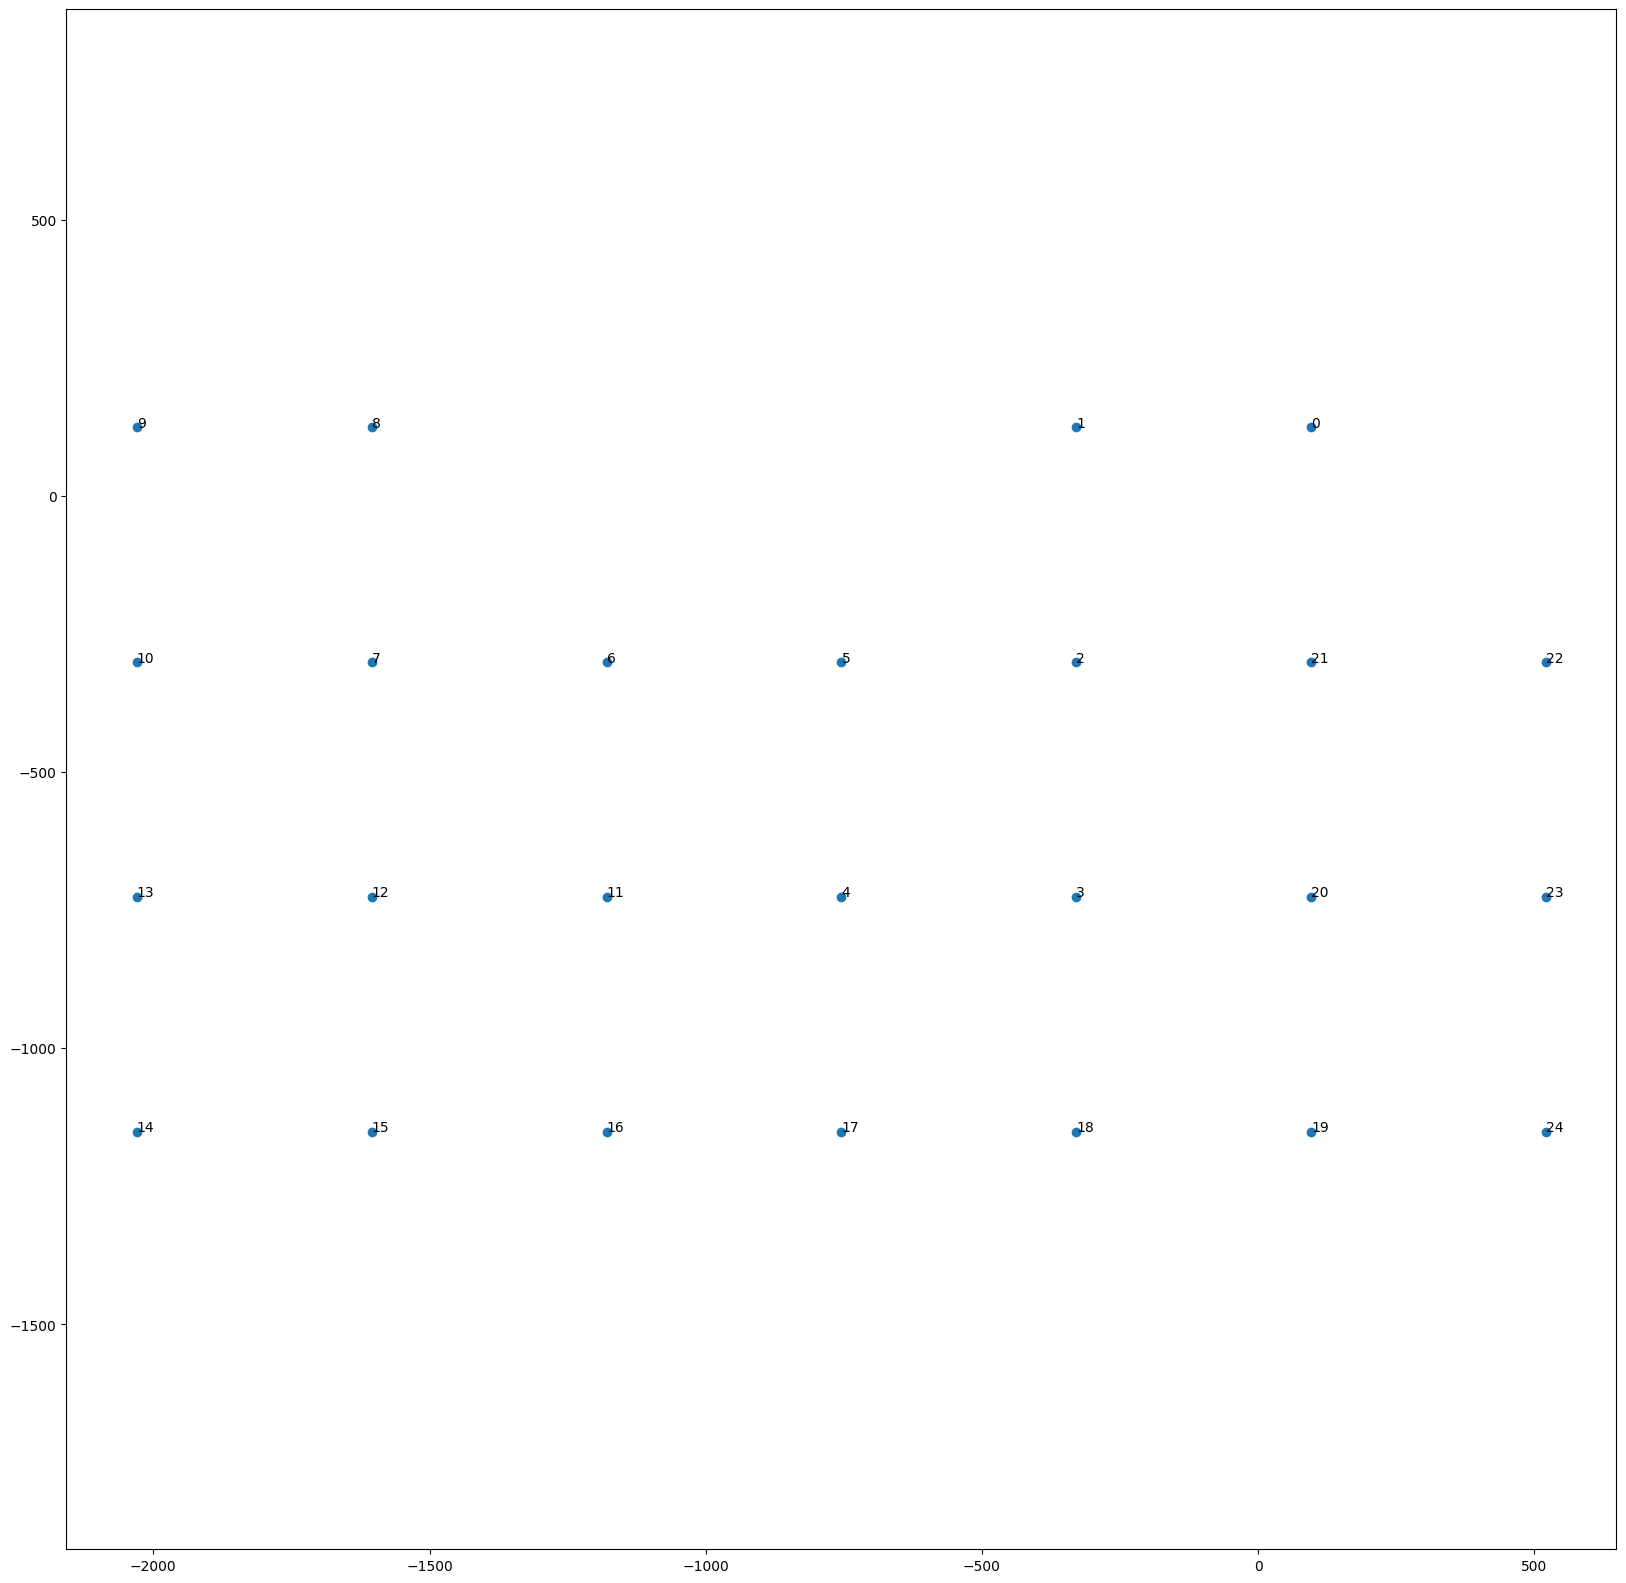

In [9]:
plt.figure(figsize=(20,20))
plt.scatter(X[:,0],X[:,1])
for i,x in enumerate(X):
    plt.text(x[0],x[1],str(i))
plt.axis('equal')

In [14]:
inds = list(range(len(X)))

In [10]:
pos_fls = glob.glob(r'F:\Jenny\110824_V3_jess_pilot\pos.*')
pos_fls

['F:\\Jenny\\110824_V3_jess_pilot\\pos.txt']

In [78]:
len(data_flds)

1

In [18]:
resc = 1 ###How much to recale
icol = 0 ### color i.e. 1-cy5, 0-750, -1 is dapi
frame = 'all'### from the zstack
for data_fld in data_flds:
    get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=True,ind=inds,tag_name='_maxp')

M:\Jenny\110824_V3_jess_pilot\mosaics\H1_P1_A1_2_3_col0_maxp.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:21<00:00, 12.85s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H1_P1_A1_2_3_col0_maxp_annot.png


In [102]:
data_flds = glob.glob(r'M:\Jenny\110824_V3_jess_pilot\H*P*')
len(data_flds)

56

In [101]:
## test round
resc = 1 ###How much to recale
icol = 0 ### color i.e. 1-cy5, 0-750, -1 is dapi
frame = 'all'### from the zstack
for data_fld in data_flds:
    get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=True,ind=inds,tag_name='', save_tiff = False)

F:\Jenny\110824_V3_jess_pilot\mosaics\H36_P2_A10_11_12_col0.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [04:34<00:00, 10.98s/it]


F:\Jenny\110824_V3_jess_pilot\mosaics\H36_P2_A10_11_12_col0_annot.png


In [104]:
## loop thru all batch 0, 1
for data_fld in data_flds:
    for icol in [0,1,2, -1]:
        get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=False,ind=inds,tag_name='', save_tiff = False)

F:\Jenny\110824_V3_jess_pilot\mosaics\H10_P1_C4_5_6_col0.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:23<00:00, 12.94s/it]


F:\Jenny\110824_V3_jess_pilot\mosaics\H10_P1_C4_5_6_col0_annot.png
F:\Jenny\110824_V3_jess_pilot\mosaics\H10_P1_C4_5_6_col1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:24<00:00, 12.99s/it]


F:\Jenny\110824_V3_jess_pilot\mosaics\H10_P1_C4_5_6_col1_annot.png
F:\Jenny\110824_V3_jess_pilot\mosaics\H10_P1_C4_5_6_col2.tiff


...

F:\Jenny\110824_V3_jess_pilot\mosaics\H9_P1_C1_2_3_col1_annot.png
F:\Jenny\110824_V3_jess_pilot\mosaics\H9_P1_C1_2_3_col2.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:19<00:00, 12.78s/it]


F:\Jenny\110824_V3_jess_pilot\mosaics\H9_P1_C1_2_3_col2_annot.png
F:\Jenny\110824_V3_jess_pilot\mosaics\H9_P1_C1_2_3_col-1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:18<00:00, 12.75s/it]


F:\Jenny\110824_V3_jess_pilot\mosaics\H9_P1_C1_2_3_col-1_annot.png


In [128]:
# data_flds = glob.glob(r'M:\Jenny\110824_V3_jess_pilot\H*P*')
data_flds = glob.glob(r'M:\Jenny\110824_V3_jess_pilot\H*')
data_flds = sorted(data_flds, key=os.path.getmtime)
len(data_flds)

90

In [125]:
data_flds[85:]

['M:\\Jenny\\110824_V3_jess_pilot\\H86_P3_E7_8_9_750',
 'M:\\Jenny\\110824_V3_jess_pilot\\H87_P3_E7_8_9_cy5',
 'M:\\Jenny\\110824_V3_jess_pilot\\H88_P3_E7_8_9',
 'M:\\Jenny\\110824_V3_jess_pilot\\H89_background']

In [111]:
## loop thru all batch 2.1
for data_fld in data_flds[56:68]:
    for icol in [0,1,2, -1]:
        get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=False,ind=inds,tag_name='', save_tiff = False)

M:\Jenny\110824_V3_jess_pilot\mosaics\H57_P2_G1_2_3_col0.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [06:01<00:00, 14.46s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H57_P2_G1_2_3_col0_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H57_P2_G1_2_3_col1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:56<00:00, 14.24s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H57_P2_G1_2_3_col1_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H57_P2_G1_2_3_col2.tiff


...

M:\Jenny\110824_V3_jess_pilot\mosaics\H68_P3_A10_11_12_col1_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H68_P3_A10_11_12_col2.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:34<00:00, 13.38s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H68_P3_A10_11_12_col2_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H68_P3_A10_11_12_col-1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:31<00:00, 13.27s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H68_P3_A10_11_12_col-1_annot.png


In [ ]:
## loop thru all batch 2.2
for data_fld in data_flds[68:]:
    for icol in [0,1,2, -1]:
        get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=False,ind=inds,tag_name='', save_tiff = False)

In [121]:
## loop thru all batch 2.2
for data_fld in data_flds[80:]:
    for icol in [0,1,2, -1]:
        get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=False,ind=inds,tag_name='', save_tiff = False)

M:\Jenny\110824_V3_jess_pilot\mosaics\H81_P3_E1_2_3_col0.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:23<00:00, 12.94s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H81_P3_E1_2_3_col0_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H81_P3_E1_2_3_col1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:17<00:00, 12.72s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H81_P3_E1_2_3_col1_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H81_P3_E1_2_3_col2.tiff


...

M:\Jenny\110824_V3_jess_pilot\mosaics\H85_P1_A1_2_3_col1_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H85_P1_A1_2_3_col2.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:22<00:00, 12.88s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H85_P1_A1_2_3_col2_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H85_P1_A1_2_3_col-1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:22<00:00, 12.91s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H85_P1_A1_2_3_col-1_annot.png


In [127]:
## loop thru all batch 3
for data_fld in data_flds[85:]:
    for icol in [0,1,2, -1]:
        get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=False,ind=inds,tag_name='', save_tiff = False)

M:\Jenny\110824_V3_jess_pilot\mosaics\H86_P3_E7_8_9_750_col0.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:19<00:00, 12.80s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H86_P3_E7_8_9_750_col0_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H86_P3_E7_8_9_750_col1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:15<00:00, 12.61s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H86_P3_E7_8_9_750_col1_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H86_P3_E7_8_9_750_col2.tiff


...

M:\Jenny\110824_V3_jess_pilot\mosaics\H89_background_col1_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H89_background_col2.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:17<00:00, 12.70s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H89_background_col2_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H89_background_col-1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:19<00:00, 12.78s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H89_background_col-1_annot.png


In [129]:
## loop thru all batch 4
for data_fld in data_flds[-1:]:
    for icol in [0,1,2, -1]:
        get_mosaic_image_T(data_fld,resc = resc,icol = icol,frame = frame,force=False,ind=inds,tag_name='', save_tiff = False)

M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col0.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:27<00:00, 13.09s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col0_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:25<00:00, 13.01s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col1_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col2.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:20<00:00, 12.83s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col2_annot.png
M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col-1.tiff


100%|██████████████████████████████████████████████████████████████████████████████████| 25/25 [05:23<00:00, 12.95s/it]


M:\Jenny\110824_V3_jess_pilot\mosaics\H90_P1_H7_8_9_col-1_annot.png


# inspect individual images on napari

In [74]:
def get_iH(fld): return int(os.path.basename(fld).replace('U','_').replace('R','_').split('_')[0][1:])

flds = glob.glob(r'M:\Jenny\110824_V3_jess_pilot\H*P*')
flds = np.array(flds)[np.argsort([get_iH(fld) for fld in flds])]
tags = [os.path.basename(fld) for fld in flds]
fovs = [os.path.basename(fl) for fl in np.sort(glob.glob(flds[0]+os.sep+'*.zarr'))]


In [25]:
# the first 7 rounds are comb

7

In [43]:
viewer = napari.Viewer()

In [45]:
# check on fov = 3
fov = fovs[4]
fls = [fld+os.sep+fov for fld in flds][7:]
from dask import array as da
ims = []
for fl in tqdm(fls):
    im = read_im(fl)
    ims.append(im[np.newaxis])
ims = da.concatenate(ims)
viewer.add_image(ims, name = f"FOV: {fov}")

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 34.31it/s]


<Image layer 'FOV: Conv_zscan__04.zarr' at 0x20fa989b160>

Viewer(camera=Camera(center=(0.0, 1399.5, 1399.5), zoom=0.28960142984807863, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(4.0, 1.0, 22.0, 0.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=5, ndisplay=2, last_used=0, range=((0.0, 10.0, 1.0), (0.0, 4.0, 1.0), (0.0, 45.0, 1.0), (0.0, 2800.0, 1.0), (0.0, 2800.0, 1.0)), current_step=(4, 1, 22, 1399, 1399), order=(0, 1, 2, 3, 4), axis_labels=('0', '1', '2', '3', '4')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'ims' at 0x20f5553d610>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x0000020E9BE59940>], _persisted_mouse_event={}, _mouse_drag_gen={}, _mouse_wheel_gen={}, keymap={})

In [75]:
flds[-5:]

array(['M:\\Jenny\\110824_V3_jess_pilot\\H52_P2_E10_11_12',
       'M:\\Jenny\\110824_V3_jess_pilot\\H53_P2_F1_2_3',
       'M:\\Jenny\\110824_V3_jess_pilot\\H54_P2_F4_5_6',
       'M:\\Jenny\\110824_V3_jess_pilot\\H55_P2_F7_8_9',
       'M:\\Jenny\\110824_V3_jess_pilot\\H56_P2_F10_11_12'], dtype='<U46')

In [76]:
# Initialize the Napari viewer
viewer = napari.Viewer()
i = 4

start = i*5
end = (i+1) *5
# Loop through all FOVs
for fov in fovs[start:end]:
# for fov in fovs:
    fls = [fld + os.sep + fov for fld in flds][-5:]  # Adjust the index if needed
    ims = []
    
    # Loop through each file in the FOV
    for fl in tqdm(fls):
        im = read_im(fl)
        ims.append(im[np.newaxis])

    # Concatenate all images for the current FOV
    ims = da.concatenate(ims)
    
    # Add the concatenated images as a new layer in the viewer
    viewer.add_image(ims, name=f"FOV: {fov}")

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 55.71it/s]
